In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import sys
import os
os.chdir('/home/jif564/bancpipeline/analysis/python/')
import cascade_model
#from cascade_model import SignalCascade
import igraph as ig
import pickle

In [2]:
def load_sqlite_database(sql_path):
    """
    Load metadata and connectivity data from SQLite database.
    
    Parameters:
    -----------
    sql_path : str
        Path to SQLite database
        
    Returns:
    --------
    tuple
        (metadata_df, edgelist_df, synapses_df)
    """
    conn = sqlite3.connect(sql_path)
    
    # List all tables (for verification)
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    print("Tables in the database:", tables)
    
    # Load all tables
    meta_df = pd.read_sql_query("SELECT * FROM meta", conn)
    try:
        edgelist_df = pd.read_sql_query("SELECT * FROM edgelist_simple", conn)
    except Exception as e:
        print("Failed to load 'edgelist_simple'. Error:", e)
        print("Attempting to load 'edgelist' instead.")
        edgelist_df = pd.read_sql_query("SELECT * FROM edgelist", conn)
    #synapses_df = pd.read_sql_query("SELECT * FROM synapses", conn)
    
    conn.close()
    return meta_df, edgelist_df


def construct_connectivity_matrix(edgelist):
    # Get unique nodes from 'pre' and 'post' columns
    nodes = pd.Index(edgelist['pre']).union(edgelist['post'])
    
    # Create a mapping of node labels to matrix indices
    node_to_index = {node: i for i, node in enumerate(nodes)}
    
    # Initialize an empty matrix with zeros
    connectivity_matrix = np.zeros((len(nodes), len(nodes)), dtype=int)
    
    # Populate the matrix with 'synaptic_count' values
    for _, row in edgelist.iterrows():
        pre_index = node_to_index[row['pre']]
        post_index = node_to_index[row['post']]
        connectivity_matrix[pre_index, post_index] += row['synaptic_count']
    
    # Convert to DataFrame for easier interpretation with node labels
    connectivity_df = pd.DataFrame(connectivity_matrix, index=nodes, columns=nodes)
    return connectivity_df


frankenbrain ask Alex:
- which is the id used to match to edgelist in metadata?
- root_id, bodyid, id what do they each mean?

MANC:
- split left right first
- nerve bundle label 
- modality label (correlated with nerve but not exactly) -> modality subtype within the nerve would be a ideal seed 

In [3]:
#sql_path = '/n/data1/hms/neurobio/wilson/banc/connectivity/frankenbrain_v.1.1_data.sqlite'
sql_path = '/n/data1/hms/neurobio/wilson/banc/connectivity/frankenbrain_v.1.1_data.sqlite'
meta_df, edgelist_df = load_sqlite_database(sql_path)

Tables in the database: [('edgelist_simple',), ('neck_bridge',), ('meta',)]


In [4]:
meta_df.columns

Index(['root_id', 'root_630', 'root_783', 'side', 'nerve', 'top_nt', 'flow',
       'super_class', 'cell_class', 'cell_sub_class', 'cell_type',
       'hemibrain_type', 'morphology_group', 'known_nt', 'known_nt_source',
       'region', 'hemilineage', 'modality', 'seed', 'top_nt_conf', 'optic',
       'flywire_xyz', 'root_recent', 'dataset', 'soma_dcv_density',
       'soma_dcv_count', 'soma_volume', 'cell_dcv_count', 'cell_dcv_avg_size',
       'known_np', 'total_outputs', 'total_inputs', 'axon_outputs',
       'dend_outputs', 'axon_inputs', 'dend_inputs', 'pd_outputs',
       'pn_outputs', 'pd_inputs', 'pn_inputs', 'total_outputs_density',
       'total_inputs_density', 'axon_outputs_density', 'dend_outputs_density',
       'axon_inputs_density', 'dend_inputs_density', 'axon_length',
       'dend_length', 'pd_length', 'pn_length', 'axon_width', 'dend_width',
       'pd_width', 'pn_width', 'segregation_index', 'projection_score', 'root',
       'nodes', 'segments', 'branchpoints', 'en

In [7]:
meta_df[meta_df.cell_type.str.contains('LH')].cell_type.unique()


array(['LHAD1a1', 'LHAD1a2', 'LHAD1a3,LHAD1f5', 'LHAD1a4a', 'LHAD1a4b',
       'LHAD1a4c', 'LHAD1b1_b', 'LHAD1b2_a,LHAD1b2_c', 'LHAD1b3',
       'LHAD1b4', 'LHAD1b5', 'LHAD1c2a', 'LHAD1c2b', 'LHAD1c2c',
       'LHAD1c3', 'LHAD1d1', 'LHAD1d2', 'LHAD1f1a', 'LHAD1f1b', 'LHAD1f2',
       'LHAD1f3a', 'LHAD1f3b', 'LHAD1f3c', 'LHAD1f3d', 'LHAD1f4a',
       'LHAD1f4b', 'LHAD1f4c', 'LHAD1h1', 'LHAD1j1', 'LHAD1k1', 'LHAD2c1',
       'LHAD2c2', 'LHAD2c3a', 'LHAD2c3c', 'LHAD3a10', 'LHAD3a8',
       'LHAD4a1', 'LHAV1a1', 'LHAV1a3', 'LHAV1b1', 'LHAV1b3', 'LHAV1d1',
       'LHAV1d2', 'LHAV2a3a', 'LHAV2a3b', 'LHAV2a3c', 'LHAV2b1',
       'LHAV2b10', 'LHAV2b11', 'LHAV2b2a', 'LHAV2b2b', 'LHAV2b6',
       'LHAV2b7_b', 'LHAV2f2_b', 'LHAV2g1b', 'LHAV2g2', 'LHAV2g3',
       'LHAV2k10', 'LHAV2k13', 'LHAV2k6', 'LHAV2m1', 'LHAV2o1', 'LHAV2p1',
       'LHAV3a1', 'LHAV3c1', 'LHAV3d1', 'LHAV3e2', 'LHAV3e3a', 'LHAV3e3b',
       'LHAV3f1', 'LHAV3g1', 'LHAV3g2', 'LHAV3h1', 'LHAV3i1', 'LHAV3k2',
       'LHAV3k3', 'LH

In [13]:
edgelist_df

,post,pre,count,post_count,pre_count,norm,6
0,720575940596125868,720575940630598927,13,191,594,0.0,6.0
1,720575940596125868,720575940638698842,11,191,136,0.0,6.0
2,720575940596125868,720575940616595515,9,191,159,0.0,6.0
3,720575940596125868,720575940625903678,8,191,152,0.0,6.0
4,720575940596125868,720575940644945608,12,191,681,0.0,6.0
...,...,...,...,...,...,...,...
20026417,99990,16647,1,366,2826,0.0,6.0
20026418,99990,16959,9,366,2345,0.0,6.0
20026419,99990,720575941584229854,4,366,14005,0.0,6.0
20026420,99990,720575941449984634,2,366,3711,0.0,6.0


In [5]:

def filter_edgelist_and_update_meta(
    edgelist_df, 
    meta_df, 
    synaptic_threshold=25
):
    """
    Filter edgelist DataFrame based on synaptic count threshold.
    Update meta_df to remove neurons without any connections and append the 'top_nt' column
    from meta_df to edgelist_df based on 'pre' and 'id'.

    Parameters:
    -----------
    edgelist_df : DataFrame
        DataFrame containing the edgelist with columns ['pre', 'post', 'count', ...].
    meta_df : DataFrame
        Metadata DataFrame containing neuron information with an 'id' column and a 'top_nt' column.
    synaptic_threshold : int, optional
        Minimum total synaptic count to retain a connection. Default is 25.

    Returns:
    --------
    tuple
        (filtered_edgelist, updated_meta, filtered_out_neurons)
    """
    # Group by 'pre' and 'post' and sum synaptic counts
    grouped_edgelist = edgelist_df.groupby(['pre', 'post'], as_index=False).agg(synaptic_count=('count', 'sum'))
    filtered_pairs = grouped_edgelist[grouped_edgelist['synaptic_count'] > synaptic_threshold][['pre', 'post']]

    # Retain only rows in the original edgelist that match the filtered pairs
    filtered_edgelist = edgelist_df.merge(filtered_pairs, on=['pre', 'post'], how='inner')

    # Append 'top_nt' from meta_df to edgelist_df
    nt_mapping = meta_df.set_index('id')['top_nt'].to_dict()
    filtered_edgelist['top_nt'] = filtered_edgelist['pre'].map(nt_mapping)

    # Determine neurons remaining in the filtered edgelist
    remaining_neurons = set(filtered_edgelist['pre']).union(set(filtered_edgelist['post']))

    # Update the meta DataFrame to remove neurons without connections
    updated_meta = meta_df[meta_df['id'].isin(remaining_neurons)].copy()

    # Return the filtered edgelist, updated metadata, and the neurons that were filtered out
    filtered_out_neurons = set(meta_df['id']) - remaining_neurons

    return filtered_edgelist, updated_meta, filtered_out_neurons



def process_filtered_edgelist_by_nt(filtered_edgelist, invert_nts=None):
    """
    Process the filtered edgelist by adding a new column 'effective_count',
    which adjusts the 'count' values based on specific neurotransmitters in
    the 'pre_top_nt' column.

    Parameters:
    -----------
    filtered_edgelist : DataFrame
        The edgelist DataFrame with columns including 'pre_top_nt' and 'count'.
    invert_nts : list of str, optional
        List of neurotransmitters for which to invert the 'count' sign.
        Default is ['gaba', 'glutamate'].

    Returns:
    --------
    processed_edgelist : DataFrame
        The modified edgelist with a new column 'effective_count'.
    """
    if invert_nts is None:
        invert_nts = ['gaba', 'glutamate']  # Default neurotransmitters to invert

    # Initialize 'effective_count' as a copy of 'count'
    filtered_edgelist['effective_count'] = filtered_edgelist['count']

    # Process each neurotransmitter in the invert list
    for nt in invert_nts:
        filtered_edgelist.loc[
            filtered_edgelist.top_nt.str.contains(nt, case=False, na=False), 
            "effective_count"
        ] *= -1

    return filtered_edgelist


In [6]:
fw_elistf, fw_meta, filtered_n = filter_edgelist_and_update_meta(edgelist_df, meta_df, synaptic_threshold=25)
fw_elistf = process_filtered_edgelist_by_nt(fw_elistf)

### Examine metadata

In [7]:
# Summarize some statistics
print("\nNetwork statistics:")
print(f"Total neurons: {len(fw_meta.id.unique())}")
print(f"Total connections: {len(fw_elistf)}")
print(f"Average synapses per connection: {fw_elistf['count'].mean():.2f}")
print("\nNeuron type distribution:")
print(fw_meta['cell_type'].value_counts())


Network statistics:
Total neurons: 108422
Total connections: 589798
Average synapses per connection: 54.49

Neuron type distribution:
cell_type
                        2669
R1-6                    2344
KCg-m                   1741
Mi1                     1565
L5                      1560
                        ... 
AN_GNG_129                 1
IN14B014                   1
AN07B051                   1
AN_GNG_134                 1
(M_adPNm4,M_adPNm5)a       1
Name: count, Length: 12039, dtype: int64


### Graph from edgelist

In [42]:
# igraph
#subset_df = fw_elistf.sample(n=50000)
g = ig.Graph.TupleList(fw_elistf[['pre', 'post']].itertuples(index=False), directed=True)


# Add weights if present
if 'synaptic_count' in fw_elistf.columns:
    g.es['synaptic_count'] = fw_elistf['synaptic_count'].tolist()


In [43]:
print(g.summary())

IGRAPH DN-- 16134 83635 -- 
+ attr: name (v), synaptic_count (e)


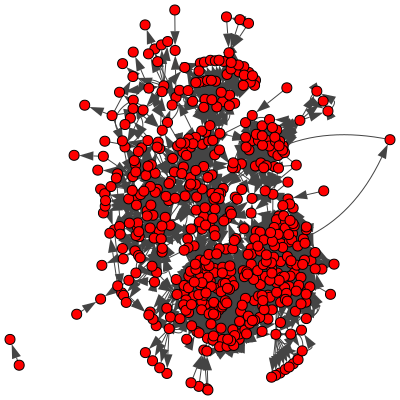

In [44]:
# Extract a subgraph for visualization (e.g., first 5 vertices)
subgraph_vertices = g.vs[:500]  # Selecting the first 100 vertices (you can modify this range)
subgraph = g.subgraph(subgraph_vertices)

# Visualize the subgraph
layout = subgraph.layout("kk")  # Kamada-Kawai layout for visualization
ig.plot(subgraph, layout=layout, vertex_size=10, bbox=(400, 400), margin=10)


### Make connectivity matrix 

In [24]:
# TODO: fix how to represent connectivity matrix
# connectivity_matrix = construct_connectivity_matrix(fw_elistf)

In [ ]:
def run_example_analysis(mask_A, mask_B):
    """
    Run example analysis with flexible criteria for selecting neuron types.

    Parameters:
    -----------
    type_criteria_S_A0 : list
        List of criteria for selecting the initial active neurons (S_A0).
    type_criteria_S_E : list
        List of criteria for selecting end neurons (S_E).
    
    Returns:
    --------
    result_dict : dict
        Results from the cascade model, including activation probabilities and masks.
    pathways : list
        Analyzed pathways from the cascade.
    """
    # Initialize the cascade model
    cascade = cascade_model.SignalCascade()
    
    # Get neuron sets from metadata based on flexible criteria
    start_neurons = set(np.array(fw_meta[mask_A]['bodyid']))
    #print(start_neurons)
    end_neurons = set(np.array(fw_meta[mask_B]['bodyid']))
    
    # Run cascade
    result_dict = cascade.run_cascade(
        S_A0=start_neurons,
        S_E=end_neurons,
        edgelist=fw_elistf,
        max_timesteps=4
    )
    activation_probs = result_dict['probabilities']
    #source_mask = result_dict['source_neurons']
    #end_mask = result_dict['end_neurons']
    
    # Analyze pathways
    #pathways = cascade.analyze_pathways(activation_probs)
    
    return result_dict


In [17]:
# Run analysis
mask_A = fw_meta["type"].str.contains("MBON09", case=False, na=False)
mask_B = fw_meta["type"].str.contains(r"FB|hdelta|vdelta", case=False, na=False)
result_dict, pathways = run_example_analysis(mask_A, mask_B)

# Basic visualization

#cascade_model.plot_cascade_results(result_dict)


### examine pkl

In [12]:
def get_activated_cells_by_timestep(activation_probabilities, index_to_neuron, end_neurons, threshold=0.1):
    """
    Retrieve the identity of activated cells at each timestep.

    Parameters:
    -----------
    activation_probabilities : np.array
        Matrix of activation probabilities per timestep (shape: [timesteps, neurons]).
    index_to_neuron : dict
        Dictionary mapping neuron indices to their original IDs in the edgelist.
    threshold : float
        Minimum activation probability threshold to consider a neuron as "activated".

    Returns:
    --------
    activated_cells : dict
        Dictionary where keys are timesteps, and values are lists of neuron IDs
        that were activated above the threshold.
    """
    activated_cells = {}
    activated_end_neurons = {}
    end_neuron_percentages = []
    end_neuron_indices = np.array(list(end_neurons))  # Convert set to an array for indexing

    for t in range(activation_probabilities.shape[0]):  # Iterate over timesteps
        # Identify neurons with activation probabilities above the threshold
        active_nodes = np.where(activation_probabilities[t] > threshold)[0]
        
        # Map the indices back to their original neuron IDs
        active_neurons_original_ids = [index_to_neuron[node] for node in active_nodes]

        # Check which of the active neurons are in the set of end neurons
        active_end_neurons = np.intersect1d(active_neurons_original_ids, end_neuron_indices)

        # Calculate the percentage of end neurons activated
        if len(end_neurons) > 0:  # Avoid division by zero
            percentage_activated = (len(active_end_neurons) / len(end_neurons)) * 100
        else:
            percentage_activated = 0.0
        
        end_neuron_percentages.append(percentage_activated)
        
        # Store the activated neurons for this timestep
        activated_cells[t] = active_neurons_original_ids
        activated_end_neurons[t] = active_end_neurons

    return activated_cells, activated_end_neurons, end_neuron_percentages

def get_unique_types_by_step(activation_dict, meta_df):
    """
    Query the unique cell types activated at each step.

    Parameters:
    -----------
    activation_dict : dict
        Dictionary where keys are timesteps, and values are lists of activated bodyids.
    meta_df : pd.DataFrame
        Metadata DataFrame containing 'bodyid' and 'type' columns.

    Returns:
    --------
    types_by_step : dict
        Dictionary where keys are timesteps, and values are sets of unique cell types activated.
    """
    types_by_step = {}

    for step, bodyids in activation_dict.items():
        # Filter the metadata for the activated bodyids at the current step
        activated_meta = meta_df[meta_df['id'].isin(bodyids)]
        
        # Get the unique types and store them
        unique_types = set(activated_meta['cell_type'])
        types_by_step[step] = unique_types

    return types_by_step

def quantify_neurons_by_name(activation_dict, meta_df, name_substring):
    """
    Quantify the percentage of activated neurons whose names contain a given string at each timestep.

    Parameters:
    -----------
    activation_dict : dict
        Dictionary where keys are timesteps, and values are lists of activated bodyids.
    meta_df : pd.DataFrame
        Metadata DataFrame containing 'bodyid' and 'type' columns.
    name_substring : str
        Substring to search for in the 'type' column of the metadata.

    Returns:
    --------
    percentages_by_step : dict
        Dictionary where keys are timesteps, and values are percentages of activated neurons 
        whose names contain the given substring.
    """
    percentages_by_step = {}

    for step, bodyids in activation_dict.items():
        # Filter the metadata for the activated bodyids at the current step
        activated_meta = meta_df[meta_df['id'].isin(bodyids)]
        
        # Find the neurons whose 'type' contains the given substring
        matching_neurons = activated_meta[activated_meta['cell_type'].str.contains(name_substring, case=False, na=False)]
        
        # Calculate the percentage
        if len(activated_meta) > 0:  # Avoid division by zero
            percentage = (len(matching_neurons) / len(activated_meta)) * 100
        else:
            percentage = 0.0
        
        # Store the percentage for the current timestep
        percentages_by_step[step] = percentage

    return percentages_by_step





In [9]:
def load_results_from_pickle(file_path):
    """
    Load a result dictionary from a pickle file.

    Parameters:
    -----------
    file_path : str
        Path to the pickle file to be loaded.

    Returns:
    --------
    result_dict : dict
        Dictionary containing the loaded results.
    """
    with open(file_path, 'rb') as f:
        result_dict = pickle.load(f)
    return result_dict

In [46]:
result_dict = load_results_from_pickle('cascade_results/olfactory_to_PAM.pkl')

In [47]:
activation_probabilities = result_dict['probabilities']
index_to_neuron = result_dict['index_to_neuron']
end_neurons = np.array(fw_meta[fw_meta["cell_type"].str.contains("PAM", case=False, na=False)]["id"])
activated_cells, activated_end_cells, end_neuron_percentages = get_activated_cells_by_timestep(activation_probabilities, index_to_neuron, end_neurons)

In [48]:
types_by_step = get_unique_types_by_step(activated_end_cells, fw_meta)
print(f'step 1: {types_by_step[1]} and FB4R present? {any("FB4R" in s for s in types_by_step[1])}')
print(f'step 2: {types_by_step[2]} and FB4R present? {any("FB4R" in s for s in types_by_step[2])}')
print(f'step 3: {types_by_step[3]} and FB4R present? {any("FB4R" in s for s in types_by_step[3])}')
print(f'step 4: {types_by_step[4]} and FB4R present? {any("FB4R" in s for s in types_by_step[4])}')
print(f'step 5: {types_by_step[5]} and FB4R present? {any("FB4R" in s for s in types_by_step[5])}')

step 1: set() and FB4R present? False
step 2: set() and FB4R present? False
step 3: set() and FB4R present? False
step 4: {'PAM08', 'PAM04', 'PAM06'} and FB4R present? False
step 5: {'PAM10', 'PAM05', 'PAM07'} and FB4R present? False


In [49]:
types_by_step

{0: set(),
 1: set(),
 2: set(),
 3: set(),
 4: {'PAM04', 'PAM06', 'PAM08'},
 5: {'PAM05', 'PAM07', 'PAM10'},
 6: {'PAM08', 'PAM09'},
 7: set(),
 8: set(),
 9: set(),
 10: set()}

In [40]:
print(f'step 1: FB5V present? {any("FB5V" in s for s in types_by_step[1])}')
print(f'step 2: FB5V present? {any("FB5V" in s for s in types_by_step[2])}')
print(f'step 3: FB5V present? {any("FB5V" in s for s in types_by_step[3])}')
print(f'step 4: FB5V present? {any("FB5V" in s for s in types_by_step[4])}')
print(f'step 5: FB5V present? {any("FB5V" in s for s in types_by_step[5])}')


step 1: FB5V present? False
step 2: FB5V present? False
step 3: FB5V present? False
step 4: FB5V present? False
step 5: FB5V present? False


In [48]:
print(f'step 1: hDelta present? {any("hDelta" in s for s in types_by_step[1])}')
print(f'step 2: hDelta present? {any("hDelta" in s for s in types_by_step[2])}')
print(f'step 3: hDelta present? {any("hDelta" in s for s in types_by_step[3])}')
print(f'step 4: hDelta present? {any("hDelta" in s for s in types_by_step[4])}')
print(f'step 5: hDelta present? {any("hDelta" in s for s in types_by_step[5])}')


step 1: hDelta present? False
step 2: hDelta present? False
step 3: hDelta present? False
step 4: hDelta present? True
step 5: hDelta present? True


In [49]:
print(f'step 1: hDeltaB present? {any("hDeltaB" in s for s in types_by_step[1])}')
print(f'step 2: hDeltaB present? {any("hDeltaB" in s for s in types_by_step[2])}')
print(f'step 3: hDeltaB present? {any("hDeltaB" in s for s in types_by_step[3])}')
print(f'step 4: hDeltaB present? {any("hDeltaB" in s for s in types_by_step[4])}')
print(f'step 5: hDeltaB present? {any("hDeltaB" in s for s in types_by_step[5])}')


step 1: hDeltaB present? False
step 2: hDeltaB present? False
step 3: hDeltaB present? False
step 4: hDeltaB present? True
step 5: hDeltaB present? True


In [51]:
print(f'step 1: hDeltaA present? {any("hDeltaA" in s for s in types_by_step[1])}')
print(f'step 2: hDeltaA present? {any("hDeltaA" in s for s in types_by_step[2])}')
print(f'step 3: hDeltaA present? {any("hDeltaA" in s for s in types_by_step[3])}')
print(f'step 4: hDeltaA present? {any("hDeltaA" in s for s in types_by_step[4])}')
print(f'step 5: hDeltaA present? {any("hDeltaA" in s for s in types_by_step[5])}')


step 1: hDeltaA present? False
step 2: hDeltaA present? False
step 3: hDeltaA present? False
step 4: hDeltaA present? False
step 5: hDeltaA present? True


In [45]:
end_neuron_percentages

[0.0,
 0.6172839506172839,
 2.57201646090535,
 9.670781893004115,
 13.991769547325102,
 8.333333333333332]

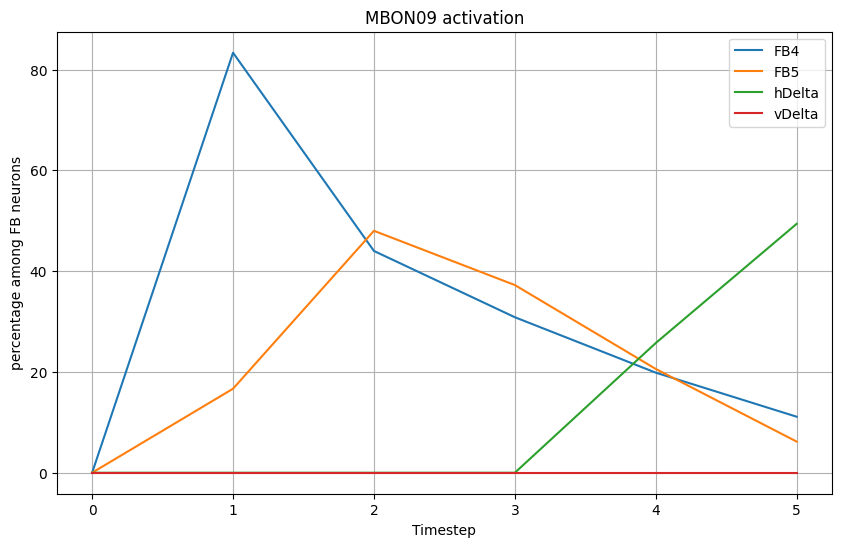

In [56]:
def plot_activation_trends_using_quantify(activation_dict, meta_df, type_list):
    """
    Calculate and visualize activation trends for multiple types using the quantify_neurons_by_name function.

    Parameters:
    -----------
    activation_dict : dict
        Dictionary where keys are timesteps, and values are lists of activated bodyids.
    meta_df : pd.DataFrame
        Metadata DataFrame containing 'bodyid' and 'type' columns.
    type_list : list
        List of strings representing neuron types or substrings to analyze.

    Returns:
    --------
    trends : dict
        Dictionary where keys are types from `type_list`, and values are lists of 
        percentages of activation per timestep.
    """
    trends = {}

    for neuron_type in type_list:
        # Use quantify_neurons_by_name to calculate trends for this neuron type
        trends[neuron_type] = list(quantify_neurons_by_name(activation_dict, meta_df, neuron_type).values())

    # Visualization
    plt.figure(figsize=(10, 6))
    for neuron_type, percentages in trends.items():
        plt.plot(list(activation_dict.keys()), percentages, label=neuron_type)

    plt.xlabel("Timestep")
    plt.ylabel("percentage among FB neurons")
    plt.title("MBON09 activation")
    plt.legend()
    plt.grid(True)
    plt.show()

    return trends

type_list = ['FB4', 'FB5', 'hDelta', 'vDelta']
trends = plot_activation_trends_using_quantify(activated_end_cells, fw_meta, type_list)


In [57]:
result_dict = load_results_from_pickle('cascade_results/cascade_results_MBON21_to_FB_hdelta_vdelta.pkl')

In [58]:
activation_probabilities = result_dict['probabilities']
index_to_neuron = result_dict['index_to_neuron']
end_neurons = np.array(fw_meta[fw_meta["type"].str.contains(r"FB|hdelta|vdelta", case=False, na=False)]["bodyid"])
activated_cells, activated_end_cells, end_neuron_percentages = get_activated_cells_by_timestep(activation_probabilities, index_to_neuron, end_neurons)

In [59]:
types_by_step = get_unique_types_by_step(activated_end_cells, fw_meta)
print(f'step 1: {types_by_step[1]} and FB4R present? {any("FB4R" in s for s in types_by_step[1])}')
print(f'step 2: {types_by_step[2]} and FB4R present? {any("FB4R" in s for s in types_by_step[2])}')
print(f'step 3: {types_by_step[3]} and FB4R present? {any("FB4R" in s for s in types_by_step[3])}')
print(f'step 4: {types_by_step[4]} and FB4R present? {any("FB4R" in s for s in types_by_step[4])}')
print(f'step 5: {types_by_step[5]} and FB4R present? {any("FB4R" in s for s in types_by_step[5])}')

step 1: {'FB4C', 'FB4R', 'FB4P_b'} and FB4R present? True
step 2: {'FB5Y', 'FB5X', 'FB4M', 'FB4I', 'FB4G', 'FB5F', 'FB4A', 'FB1H', 'FB4Y', 'FB5Q'} and FB4R present? False
step 3: {'FB4O', 'FB6M', 'FB2L', 'FB5Y', 'FB2B_a', 'FB5AB', 'FB5D', 'FB6A', 'hDeltaK', 'FB4M', 'FB6T', 'FB6H', 'FB5A', 'FB5L', 'FB4D', 'FB4F_b', 'FB7E', 'FB5K', 'FB4J', 'FB4H', 'FB5X', 'FB6D', 'FB8I', 'FB5P', 'FB5N', 'FB8F_b', 'FB7L', 'FB8F_a', 'FB6E', 'FB2G_a', 'FB4X', 'FB3A', 'FB5G', 'FB5H', 'FB4P_b', 'FB5F', 'FB5Z', 'FB5T', 'FB6N', 'FB6V', 'FB4Q_b', 'FB4F_a', 'FB5B', 'FB4N', 'FB4I', 'FB5I', 'FB4G', 'FB6U', 'FB1G', 'FB4P_a', 'FB4Q_a', 'FB4K', 'FB6X', 'FB2M', 'FB5V', 'FB5Q'} and FB4R present? False
step 4: {'FB6F', 'FB4O', 'FB2A', 'FB6M', 'FB5C', 'FB2L', 'FB2G_b', 'FB5Y', 'FB5D', 'FB6A', 'hDeltaK', 'FB6H', 'FB5O', 'FB5AA', 'FB2K', 'FB4D', 'FB4F_b', 'FB7E', 'FB1F', 'FB7I', 'FB5X', 'FB6D', 'FB2I_b', 'FB6B', 'FB5P', 'hDeltaB', 'FB8C', 'FB4B', 'FB5N', 'FB4Y', 'FB4C', 'FB3A', 'FB5G', 'FB5E', 'FB3D', 'FB4L', 'hDeltaH', 'FB

In [60]:
print(f'step 1: FB5V present? {any("FB5V" in s for s in types_by_step[1])}')
print(f'step 2: FB5V present? {any("FB5V" in s for s in types_by_step[2])}')
print(f'step 3: FB5V present? {any("FB5V" in s for s in types_by_step[3])}')
print(f'step 4: FB5V present? {any("FB5V" in s for s in types_by_step[4])}')
print(f'step 5: FB5V present? {any("FB5V" in s for s in types_by_step[5])}')


step 1: FB5V present? False
step 2: FB5V present? False
step 3: FB5V present? True
step 4: FB5V present? True
step 5: FB5V present? False


In [61]:
print(f'step 1: hDelta present? {any("hDelta" in s for s in types_by_step[1])}')
print(f'step 2: hDelta present? {any("hDelta" in s for s in types_by_step[2])}')
print(f'step 3: hDelta present? {any("hDelta" in s for s in types_by_step[3])}')
print(f'step 4: hDelta present? {any("hDelta" in s for s in types_by_step[4])}')
print(f'step 5: hDelta present? {any("hDelta" in s for s in types_by_step[5])}')


step 1: hDelta present? False
step 2: hDelta present? False
step 3: hDelta present? True
step 4: hDelta present? True
step 5: hDelta present? True


In [62]:
print(f'step 1: hDeltaB present? {any("hDeltaB" in s for s in types_by_step[1])}')
print(f'step 2: hDeltaB present? {any("hDeltaB" in s for s in types_by_step[2])}')
print(f'step 3: hDeltaB present? {any("hDeltaB" in s for s in types_by_step[3])}')
print(f'step 4: hDeltaB present? {any("hDeltaB" in s for s in types_by_step[4])}')
print(f'step 5: hDeltaB present? {any("hDeltaB" in s for s in types_by_step[5])}')


step 1: hDeltaB present? False
step 2: hDeltaB present? False
step 3: hDeltaB present? False
step 4: hDeltaB present? True
step 5: hDeltaB present? True


In [63]:
print(f'step 1: hDeltaA present? {any("hDeltaA" in s for s in types_by_step[1])}')
print(f'step 2: hDeltaA present? {any("hDeltaA" in s for s in types_by_step[2])}')
print(f'step 3: hDeltaA present? {any("hDeltaA" in s for s in types_by_step[3])}')
print(f'step 4: hDeltaA present? {any("hDeltaA" in s for s in types_by_step[4])}')
print(f'step 5: hDeltaA present? {any("hDeltaA" in s for s in types_by_step[5])}')


step 1: hDeltaA present? False
step 2: hDeltaA present? False
step 3: hDeltaA present? False
step 4: hDeltaA present? False
step 5: hDeltaA present? True


In [24]:
result_dict = load_results_from_pickle('cascade_results/cascade_results_664978073_818796911_850182049_1132150724_to_rMBON_PAM_PPL.pkl')
activation_probabilities = result_dict['probabilities']
index_to_neuron = result_dict['index_to_neuron']
end_neurons = np.array(fw_meta[fw_meta["type"].str.contains(r"MBON|PAM|PPL", case=False, na=False)]["bodyid"])
activated_cells, activated_end_cells, end_neuron_percentages = get_activated_cells_by_timestep(activation_probabilities, index_to_neuron, end_neurons)

In [25]:
types_by_step = get_unique_types_by_step(activated_end_cells, fw_meta)
print(f'step 1: {types_by_step[1]} and PAM12 present? {any("PAM12" in s for s in types_by_step[1])}')
print(f'step 2: {types_by_step[2]} and PAM12 present? {any("PAM12" in s for s in types_by_step[2])}')
print(f'step 3: {types_by_step[3]} and PAM12 present? {any("PAM12" in s for s in types_by_step[3])}')
print(f'step 4: {types_by_step[4]} and PAM12 present? {any("PAM12" in s for s in types_by_step[4])}')
print(f'step 5: {types_by_step[5]} and PAM12 present? {any("PAM12" in s for s in types_by_step[5])}')

step 1: set() and PAM12 present? False
step 2: {'MBON30', 'MBON35'} and PAM12 present? False
step 3: {'MBON16', 'MBON04', 'MBON31', 'MBON17', 'MBON29', 'MBON26', 'MBON06', 'MBON24', 'PAM08_b', 'PPL107', 'MBON20', 'MBON27'} and PAM12 present? False
step 4: {'PAM06_a', 'MBON33', 'MBON15', 'MBON21', 'MBON35', 'PPL107', 'MBON13', 'MBON19', 'PPL101', 'PPL108', 'PPL102', 'PAM10', 'MBON14', 'MBON17-like', 'PPL203', 'PPL104', 'PAM08_d', 'MBON03', 'PAM05', 'PPL201', 'PPL106', 'PPL105', 'MBON31', 'MBON12', 'MBON32', 'MBON15-like', 'MBON10', 'MBON18', 'MBON23', 'PAM08_c', 'MBON28', 'MBON05', 'MBON22', 'PAM11', 'PPL204', 'MBON02', 'PPL103', 'MBON09', 'MBON16', 'MBON11', 'PPL202', 'MBON01', 'PAM08_b', 'PAM14', 'MBON07'} and PAM12 present? False
step 5: {'PAM06_a', 'MBON15', 'MBON21', 'PAM15_a', 'PPL108', 'MBON25', 'PAM15_b', 'PAM10', 'MBON17-like', 'PPL203', 'PAM02', 'PPL104', 'PAM08_a', 'PAM13', 'PAM12', 'PAM01_a', 'PPL106', 'PAM04_b', 'MBON31', 'MBON15-like', 'PAM06_b', 'MBON10', 'PAM08_c', 'MBON

In [26]:
print(f'step 1: PAM08 present? {any("PAM08" in s for s in types_by_step[1])}')
print(f'step 2: PAM08 present? {any("PAM08" in s for s in types_by_step[2])}')
print(f'step 3: PAM08 present? {any("PAM08" in s for s in types_by_step[3])}')
print(f'step 4: PAM08 present? {any("PAM08" in s for s in types_by_step[4])}')
print(f'step 5: PAM08 present? {any("PAM08" in s for s in types_by_step[5])}')


step 1: PAM08 present? False
step 2: PAM08 present? False
step 3: PAM08 present? True
step 4: PAM08 present? True
step 5: PAM08 present? True


In [27]:
print(f'step 1: PAM07 present? {any("PAM07" in s for s in types_by_step[1])}')
print(f'step 2: PAM07 present? {any("PAM07" in s for s in types_by_step[2])}')
print(f'step 3: PAM07 present? {any("PAM07" in s for s in types_by_step[3])}')
print(f'step 4: PAM07 present? {any("PAM07" in s for s in types_by_step[4])}')
print(f'step 5: PAM07 present? {any("PAM07" in s for s in types_by_step[5])}')


step 1: PAM07 present? False
step 2: PAM07 present? False
step 3: PAM07 present? False
step 4: PAM07 present? False
step 5: PAM07 present? True


In [28]:
print(f'step 1: MBON21 present? {any("MBON21" in s for s in types_by_step[1])}')
print(f'step 2: MBON21 present? {any("MBON21" in s for s in types_by_step[2])}')
print(f'step 3: MBON21 present? {any("MBON21" in s for s in types_by_step[3])}')
print(f'step 4: MBON21 present? {any("MBON21" in s for s in types_by_step[4])}')
print(f'step 5: MBON21 present? {any("MBON21" in s for s in types_by_step[5])}')


step 1: MBON21 present? False
step 2: MBON21 present? False
step 3: MBON21 present? False
step 4: MBON21 present? True
step 5: MBON21 present? True


In [29]:
print(f'step 1: MBON09 present? {any("MBON09" in s for s in types_by_step[1])}')
print(f'step 2: MBON09 present? {any("MBON09" in s for s in types_by_step[2])}')
print(f'step 3: MBON09 present? {any("MBON09" in s for s in types_by_step[3])}')
print(f'step 4: MBON09 present? {any("MBON09" in s for s in types_by_step[4])}')
print(f'step 5: MBON09 present? {any("MBON09" in s for s in types_by_step[5])}')


step 1: MBON09 present? False
step 2: MBON09 present? False
step 3: MBON09 present? False
step 4: MBON09 present? True
step 5: MBON09 present? True
